Вариант задания определяется согласно предложенному скрипту:

In [1]:
surname = "Новиков"  # Ваша фамилия

alph = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
w = [4, 42, 21, 21, 55,  1, 44, 26, 18, 3, 38, 26, 18, 12,  3, 49, 45,
        7, 42, 9,  4,  3, 36, 33, 31, 29,  5, 4,  4, 19, 21, 27, 33]
d = dict(zip(alph, w))
variant =  sum([d[el] for el in surname.lower()]) % 40 + 1

print("Задание № 2. Вариант: ", variant % 2 + 1)
print("Задание № 3. Вариант: ", variant % 3 + 1 )

Задание № 2. Вариант:  2
Задание № 3. Вариант:  2


# Задача 1. Реализация собственных классов и функций

## 1 пункт
Реализовать класс, предназначенный для оценки параметров линейной регрессии с регуляризацией совместимый с `sklearn`. 

Передаваемые параметры: 
1. коэффициент регуляризации (*alpha*). 

Использовать **метод наименьших квадратов с регуляризацией**.

Подключаем необходимые библиотеки:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

Определим класс, реализующий ридж-регрессию (*формула известна*).

Класс будет оценивать параметры линейной регрессии с заданной регуляризацией.

Родительским для нашего класса будут: 
* `BaseEstimator` - базовый для всех моделей в sklearn
* `RegressorMixin` - это добавка, которая говорит: "модель — это регрессор"

In [3]:
class CustomLinearRegression(BaseEstimator, RegressorMixin):
    
    def __init__(self, alpha=1.0, method='ridge'):
        self.alpha = alpha
        self.method = method
    
    def fit(self, X, y):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = X_b.shape[1]
        I = np.eye(n_features)
        I[0, 0] = 0
        self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.coef_

Теперь проверим написаный класс на практике. 
Для этого подготовим данные, с которыми будем работать

In [4]:
def generate_data(n=100, start_x=4, length_x=8, mu=0, sigma=0.5):
    """Генерация данных."""
    from scipy import stats
    f = lambda x: 2 + 0.3*x
    x = stats.uniform.rvs(size=n, loc=start_x, scale=length_x, random_state=1)
    e = stats.norm.rvs(size=n, loc=mu, scale=sigma, random_state=1)
    return x.reshape(-1,1), f(x) + e

In [5]:
def plot_regression(X, y, model=None):
    """
    Функция для отображения наблюдений и линии регрессии.

    Parameters:
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    model : объект модели, который имеет метод predict
        Модель, предсказывающая значения для регрессионной линии.
    """
    plt.figure(2, figsize=[4, 4])
    
    xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 2).reshape(-1, 1)

    plt.subplot(1, 1, 1)
    plt.scatter(X[:, 0], y, color="green", label="Sample", zorder=2)
    if model:
        plt.plot(xx, model.predict(xx), "-", color="grey", label="Regression")
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
X, y = generate_data()

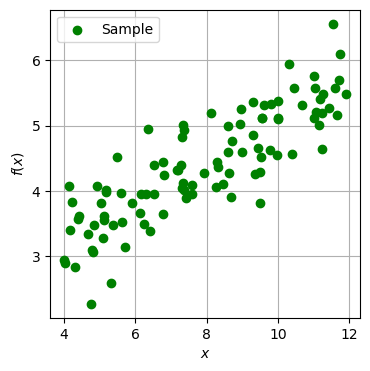

In [7]:
# Отображение наблюдений
plot_regression(X, y)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Разбиение данных на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
X_train[:5], y_train[:5]

(array([[6.24355194],
        [9.53501691],
        [6.15942313],
        [5.69302493],
        [6.52412505]]),
 array([3.49948643, 4.52488201, 3.9469768 , 3.13664838, 3.95090521]))

In [10]:
model = CustomLinearRegression()

In [11]:
# Обучение
model.fit(X_train, y_train)
model.coef_

array([1.90471493, 0.30801062])

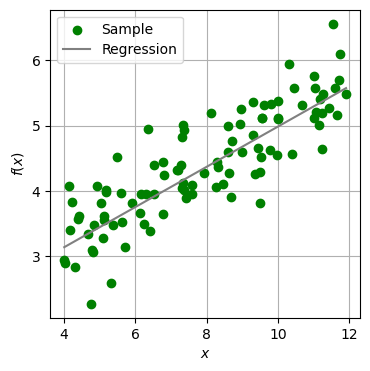

In [12]:
# Отображение наблюдений и линии регрессии
plot_regression(X, y, model)

In [13]:
model.score(X_test, y_test)

0.7111923560425083

как видно, получена точность 70%

## 2 пункт

Реализовать класс, предназначенный для для стандартизации признаков в виде трансформации совместимый с `sklearn`. 

Передаваемые параметры: 
1. has_bias (содержит ли матрица вектор единиц), 
2. apply_mean (производить ли центровку)

In [14]:
class CustomStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, has_bias=False, apply_mean=True):
        self.has_bias = has_bias
        self.apply_mean = apply_mean

    def fit(self, X, y=None):
        X = check_array(X)

        start_col = 1 if self.has_bias else 0
        self.mean_ = np.zeros(X.shape[1])
        self.std_ = np.ones(X.shape[1])

        if self.apply_mean:
            self.mean_[start_col:] = np.mean(X[:, start_col:], axis=0)
        self.std_[start_col:] = np.std(X[:, start_col:], axis=0, ddof=0)

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "std_"])
        X = check_array(X)

        X_scaled = (X - self.mean_) / self.std_
        if self.has_bias:
            X_scaled[:, 0] = X[:, 0]  # не трогаем bias-столбец

        return X_scaled

Создадим экземпляр нового класса:

In [15]:
scaler = CustomStandardScaler()

In [16]:
# Стандартизируем данные
scaler.fit(X)
X_scaled = scaler.transform(X)
# Отображение X
print("Исходные данные X:")
print(X[:5])

print("\nСтандартизированные данные X_scaled:")
print(X_scaled[:5])

Исходные данные X:
[[7.33617604]
 [9.76259595]
 [4.000915  ]
 [6.41866058]
 [5.17404713]]

Стандартизированные данные X_scaled:
[[-0.23388437]
 [ 0.79634961]
 [-1.65000333]
 [-0.62345239]
 [-1.15190299]]


## 3 пункт

Реализуйте функции для расчета MSE и R^2 при отложенной выборке (run_holdout) и кросс-валидации (run_cross_val). Для кросс-валидации используйте только класс KFold. Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

Реализовать функции для расчета:
* MSE 
* R^2 

при: 
* отложенной выборке (run_holdout)
* кросс-валидации (run_cross_val) 

Для кросс-валидации используйте только класс KFold.
Выходными значениями должны быть MSE и R^2 для обучающей и тестовой частей.

In [17]:
# import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

def run_holdout(model, X, y, train_size, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 на отложенной выборке (holdout).
    
    Parameters:
    model : объект модели с методами fit и predict
        Модель, которая обучается и делает предсказания.
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    train_size : float
        Доля данных для обучения (от 0 до 1).
    random_state : int
        Сеятель для случайных операций (например, для разделения данных).
    
    Returns:
    dict : словарь с MSE и R^2 для обучающей и тестовой выборки
    """
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_state)

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказания для обучающей выборки
    y_train_pred = model.predict(X_train)
    # Предсказания для тестовой выборки
    y_test_pred = model.predict(X_test)

    # Вычисление MSE и R^2 для обучающей выборки
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Вычисление MSE и R^2 для тестовой выборки
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Возвращаем результаты в виде словаря
    scores = {
        "train_mse": mse_train,
        "train_r2": r2_train,
        "test_mse": mse_test,
        "test_r2": r2_test
    }

    return scores

In [18]:
def run_cross_val(model, X, y, n_splits, shuffle, random_state) -> dict:
    """
    Функция для расчета MSE и R^2 при кросс-валидации с использованием KFold.
    
    Parameters:
    model : объект модели с методами fit и predict
        Модель, которая обучается и делает предсказания.
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    n_splits : int
        Количество разбиений для кросс-валидации.
    shuffle : bool
        Нужно ли перемешивать данные перед разбиением.
    random_state : int
        Сеятель для случайных операций.
    
    Returns:
    dict : словарь с MSE и R^2 для обучающей и тестовой частей
    """
    # KFold для кросс-валидации
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    # Списки для хранения значений MSE и R^2
    mse_train_list = []
    r2_train_list = []
    mse_test_list = []
    r2_test_list = []

    # Кросс-валидация
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказания для обучающей выборки
        y_train_pred = model.predict(X_train)
        # Предсказания для тестовой выборки
        y_test_pred = model.predict(X_test)

        # Вычисление MSE и R^2 для обучающей выборки
        mse_train = mean_squared_error(y_train, y_train_pred)
        r2_train = r2_score(y_train, y_train_pred)

        # Вычисление MSE и R^2 для тестовой выборки
        mse_test = mean_squared_error(y_test, y_test_pred)
        r2_test = r2_score(y_test, y_test_pred)

        # Добавляем результаты в списки
        mse_train_list.append(mse_train)
        r2_train_list.append(r2_train)
        mse_test_list.append(mse_test)
        r2_test_list.append(r2_test)

    # Средние значения для MSE и R^2
    scores = {
        "mean_train_mse": np.mean(mse_train_list),
        "mean_train_r2": np.mean(r2_train_list),
        "mean_test_mse": np.mean(mse_test_list),
        "mean_test_r2": np.mean(r2_test_list)
    }

    return scores

Протестируем функции на практике:

In [19]:
# Примерные данные X и y
# X = np.random.rand(100, 2)
# y = np.random.rand(100)

# Отложенная выборка
holdout_scores = run_holdout(model, X, y, train_size=0.8, random_state=42)
print("Holdout Scores:\n", holdout_scores, "\n\n")

# Кросс-валидация
cross_val_scores = run_cross_val(model, X, y, n_splits=5, shuffle=True, random_state=42)
print("Cross-validation Scores:\n", cross_val_scores)


Holdout Scores:
 {'train_mse': 0.20060731131054932, 'train_r2': 0.7339481247612263, 'test_mse': 0.1812359709481102, 'test_r2': 0.6267901195830992} 


Cross-validation Scores:
 {'mean_train_mse': 0.1942808734351977, 'mean_train_r2': 0.7215030554708867, 'mean_test_mse': 0.21016659462620768, 'mean_test_r2': 0.6738807716395928}


## 4 пункт

Используя класс `Pipeline`, выполнить обучение линейной регрессии с предварительной стандартизацией с коэффициентом регуляризации равным 0 и 0.01. 
* Вывести значения параметров обученной модели. 
* Вывести значения `MSE` и `R^2`, полученные посредством функций `run_holdout` и `run_cross_val`. 
* Отобразить график **предсказание - действительное значение** для разных коэффициентов регуляризации для обучающего и текстового множества. 

Использовать следующие параметры:

- train_size=0.75,
- n_splits=4,
- shuffle=True,
- random_state=0

⚠️ Замечание. При формировании исходных данных использовался полином 16 степени одномерных данных.

In [20]:
from sklearn.pipeline import Pipeline


=== Alpha = 0 ===
Коэффициенты модели: [4.39639845 0.71114223]

Holdout:
{'train_mse': 0.20403517416841843, 'train_r2': 0.6882911818517201, 'test_mse': 0.1904719903557419, 'test_r2': 0.746395386565615}
Cross-validation:
{'mean_train_mse': 0.1940388322935528, 'mean_train_r2': 0.7214168974847806, 'mean_test_mse': 0.20873592398349344, 'mean_test_r2': 0.6807279641713322}


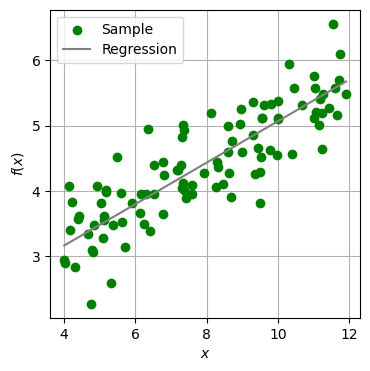


=== Alpha = 0.01 ===
Коэффициенты модели: [4.39639845 0.71107112]

Holdout:
{'train_mse': 0.20403518217578723, 'train_r2': 0.6882911696186947, 'test_mse': 0.19051354078485525, 'test_r2': 0.7463400640980246}
Cross-validation:
{'mean_train_mse': 0.19403884124792353, 'mean_train_r2': 0.7214168846630107, 'mean_test_mse': 0.20873475751402062, 'mean_test_r2': 0.6807358980991809}


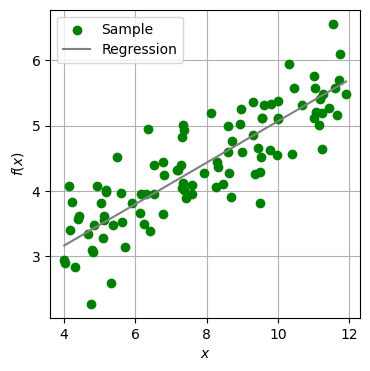

In [21]:
alphas = [0, 0.01]
train_size = 0.75
n_splits = 4
shuffle = True
random_state = 0

for alpha in alphas:
    print(f"\n=== Alpha = {alpha} ===")
    
    pipeline = Pipeline([
        ('scaler', CustomStandardScaler(has_bias=False, apply_mean=True)),
        ('customlinearregression', CustomLinearRegression(alpha=alpha))
    ])
    
    # --- Обучение
    pipeline.fit(X, y)
    
    # --- Коэффициенты
    coef = pipeline.named_steps['customlinearregression'].coef_
    print(f"Коэффициенты модели: {coef}\n")
    
    # --- Метрики: Holdout
    holdout_scores = run_holdout(pipeline, X, y, train_size, random_state)
    print("Holdout:")
    print(holdout_scores)
    
    # --- Метрики: Cross-validation
    cv_scores = run_cross_val(pipeline, X, y, n_splits, shuffle, random_state)
    print("Cross-validation:")
    print(cv_scores)
    
    # --- График
    plot_regression(X, y, pipeline)

# Задача 2. Классификация и кросс-валидация

Дан набор входных данных (_вариант 2_)

Надо:
1. Найти степень полинома с **минимальной ошибкой** на проверочном подмножестве. 
2. Для лучшего случая рассчитать **ошибку на тестовом** подмножестве. 
В качестве метрики использовать долю правильных классификаций. 
4. Сделать заключение о **влиянии степени полинома на качество** предсказания.

Построить:

- **диаграмму разброса** исходных данных
- зависимость доли **правильных классификаций от степени полинома** для обучающего и проверочного подмножеств (две кривые на одном графике)
- **результат классификации** для наилучшего случая (степень полинома) для обучающего и тестового подмножеств с указанием границы принятия решения

Загрузим данные:

In [22]:
import pandas as pd

In [23]:
data = pd.read_csv('./Cl_A5_V2.csv')
X = data.iloc[:, :-1].values  # все колонки кроме последней
y = data.iloc[:, -1].values   # последняя колонка — метка класса

Для исходных данных построим диаграмму разброса

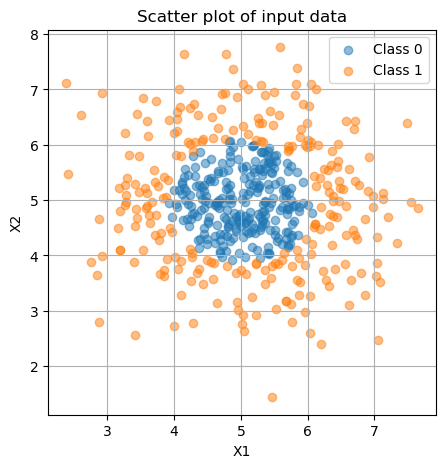

In [24]:
plt.figure(figsize=(5, 5))
plt.scatter(X[y==0][:,0], X[y==0][:,1], label='Class 0', alpha=0.5)
plt.scatter(X[y==1][:,0], X[y==1][:,1], label='Class 1', alpha=0.5)
plt.title("Scatter plot of input data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()

Зададим параметры логистической регрессии

In [25]:
logreg_params = {
    'penalty': 'l2',
    'fit_intercept': True,
    'max_iter': 100,
    'C': 1e5,
    'solver': 'liblinear',
    'random_state': 12345
}

Разобьем исходные данные:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=0)

Поиск наилучшей степени полинома:

In [27]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

In [28]:
degrees = range(1, 11)
train_scores = []
val_scores = []

best_degree = None
best_score = 0
best_model = None

# --- Подбор степени полинома по отложенной выборке
for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**logreg_params))
    ])
    pipe.fit(X_train, y_train)

    acc_train = pipe.score(X_train, y_train)
    acc_val = pipe.score(X_test, y_test)

    train_scores.append(acc_train)
    val_scores.append(acc_val)

    if acc_val > best_score:
        best_score = acc_val
        best_degree = d
        best_model = pipe

# --- Вывод лучшей степени и точности
print(f"Лучшая степень полинома по отложенной выборке: {best_degree}")
print(f"Accuracy на тестовом множестве: {best_score:.4f}\n")

Лучшая степень полинома по отложенной выборке: 2
Accuracy на тестовом множестве: 1.0000



График зависимости точности от степени:

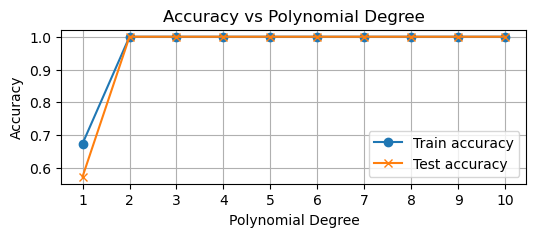

In [29]:
plt.figure(figsize=(6, 2))
plt.plot(degrees, train_scores, label='Train accuracy', marker='o')
plt.plot(degrees, val_scores, label='Test accuracy', marker='x')
plt.title("Accuracy vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(degrees) 
plt.grid(True)
plt.show()

отобразим границу классификации более наглядно:

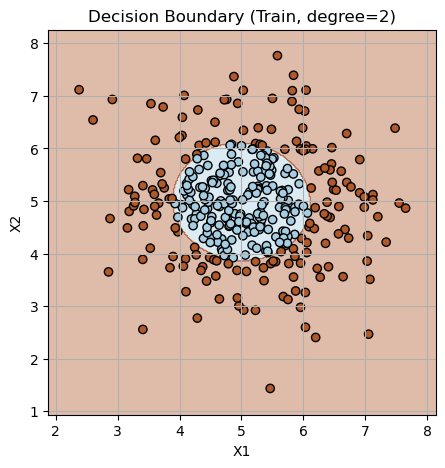

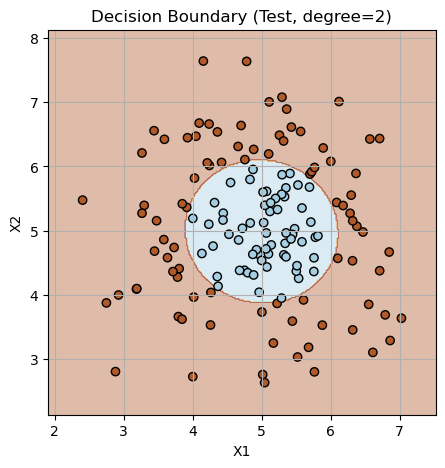

In [30]:
def plot_decision_boundary(model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(best_model, X_train, y_train,
                       f"Decision Boundary (Train, degree={best_degree})")
plot_decision_boundary(best_model, X_test, y_test,
                       f"Decision Boundary (Test, degree={best_degree})")

Проведем кроссвалидацию модели

In [31]:
from sklearn.model_selection import cross_validate

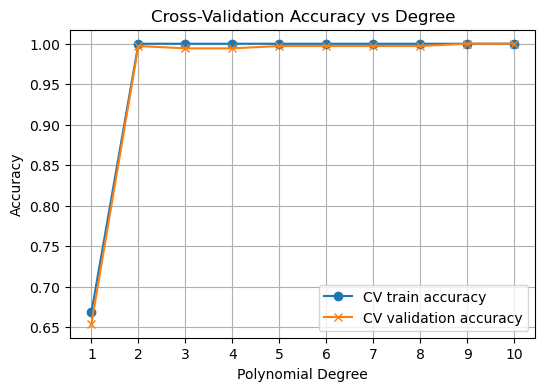

Лучшая степень по кросс-валидации: 9


In [32]:
cv_scores = []
cv_train_scores = []

for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**logreg_params))
    ])
    scores = cross_validate(pipe, X_train, y_train,
                            cv=4, scoring='accuracy',
                            return_train_score=True)
    cv_train_scores.append(np.mean(scores['train_score']))
    cv_scores.append(np.mean(scores['test_score']))

# --- Вывод результатов кросс-валидации
plt.figure(figsize=(6, 4))
plt.plot(degrees, cv_train_scores, label='CV train accuracy', marker='o')
plt.plot(degrees, cv_scores, label='CV validation accuracy', marker='x')
plt.title("Cross-Validation Accuracy vs Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.legend()
plt.xticks(degrees) 
plt.grid(True)
plt.show()

# --- Заключение
best_cv_deg = degrees[np.argmax(cv_scores)]
print(f"Лучшая степень по кросс-валидации: {best_cv_deg}")

# Задача 3. Классификация текстовых документов
### Вариант 2. Набор SMS сообщений (sms)

SMSSpamCollection

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report


Подготовим данные, т.е. загрузим их и разобьем в отношении 80 на 20

In [ ]:
data = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'text'])
data['label'] = df['label'].map({'ham': 0, 'spam': 1})

X = data['text']
y = data['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=123)

В этом задании нам надо найти лучшие гиперпараметры для разных классификаторов


Классификаторы:

In [ ]:
classifiers = {
    'knn': KNeighborsClassifier(),
    'logreg': LogisticRegression(penalty='l2', fit_intercept=True, max_iter=100, C=1e5,
                                 solver='liblinear', random_state=123),
    'bernoulli': BernoulliNB(),
    'multinomial': MultinomialNB()
}

Гиперпараметры:

In [ ]:
param_grids = {
    'knn': {'clf__n_neighbors': np.arange(1, 150, 20)},
    'logreg': {'clf__C': np.logspace(-2, 10, 8, base=10)},
    'bernoulli': {'clf__alpha': np.logspace(-4, 1, 8, base=10)},
    'multinomial': {'clf__alpha': np.logspace(-4, 1, 8, base=10)}
}

Разобьем задачу на логические шаги:

### 1
первым шагом надо найти лучшие гиперпараметры, при помощи стратифицированной кросс-валидации. 
> _Также сразу замерим время обучения._

In [ ]:
def run_grid_search(pipeline, param_grid, X, y, cv, scoring='balanced_accuracy'):
    grid = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)
    start_train = time.time()
    grid.fit(X, y)
    train_time = time.time() - start_train
    return grid, train_time

### 2
после необходимо отобразить модель

In [ ]:
def plot_grid_scores(grid, param_name, title):
    results = pd.DataFrame(grid.cv_results_)
    plt.figure()
    plt.plot(results['param_' + param_name], results['mean_train_score'], label='Train')
    plt.plot(results['param_' + param_name], results['mean_test_score'], label='Validation')
    plt.xscale('log' if results['param_' + param_name].dtype == np.float64 else 'linear')
    plt.xlabel(param_name)
    plt.ylabel('Balanced Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 3
Наконец надо собрать статистику по каждому классификатору, а именно:
* Balanced-Accuracy
* R
* P 
* F1

In [34]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }


============== N-gram: (1, 1) ==============
>>>>>>> Model: knn


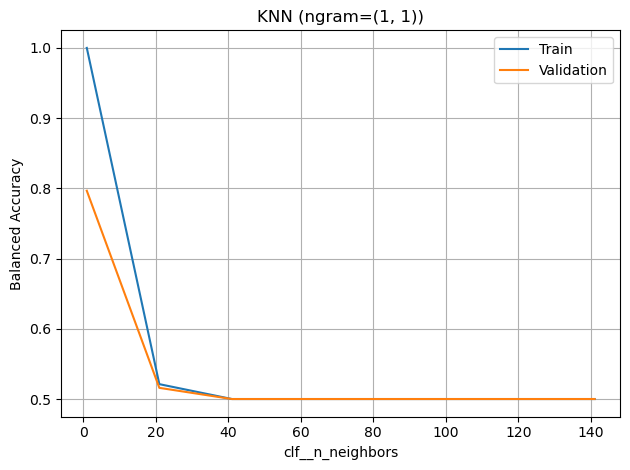

>>>>>>> Model: logreg


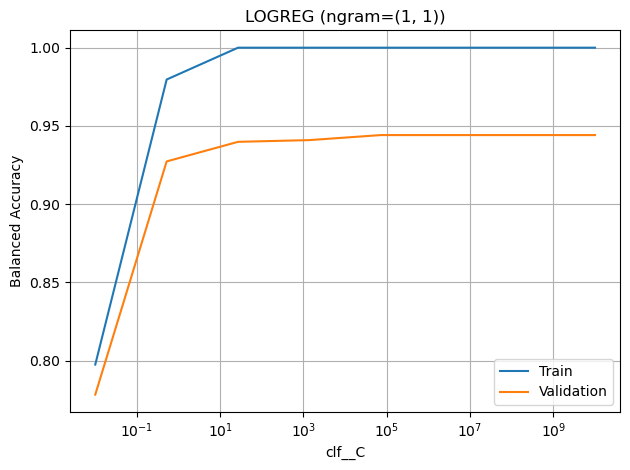

>>>>>>> Model: bernoulli


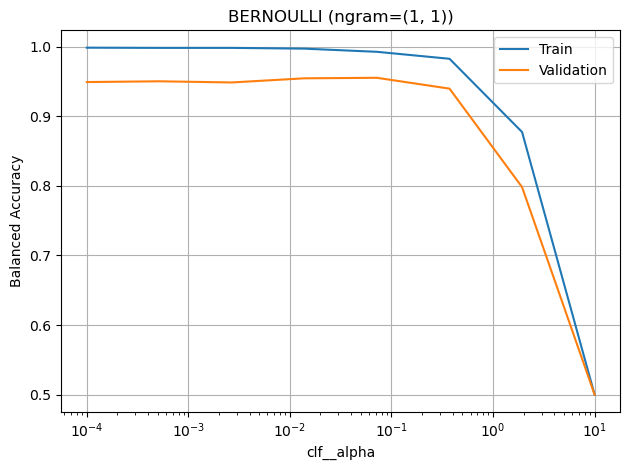

>>>>>>> Model: multinomial


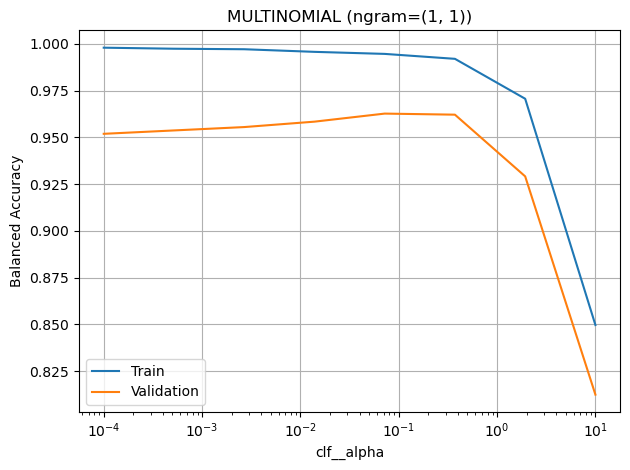


============== N-gram: (2, 2) ==============
>>>>>>> Model: knn


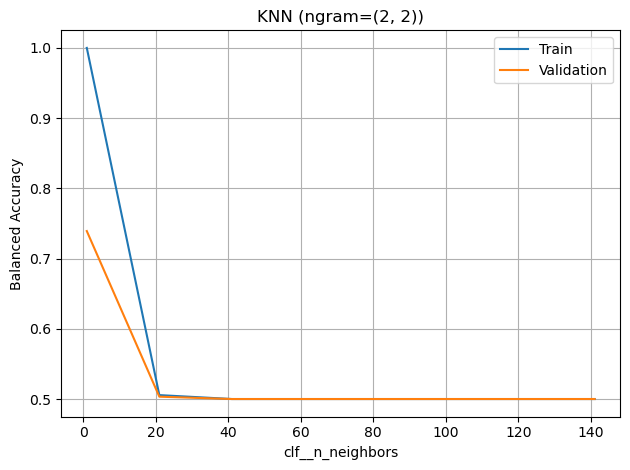

>>>>>>> Model: logreg


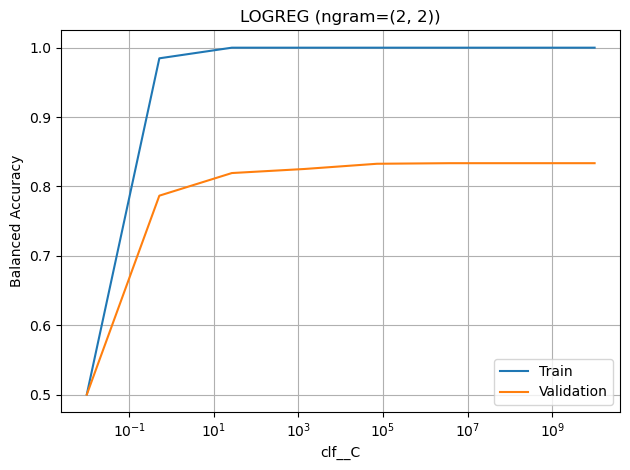

>>>>>>> Model: bernoulli


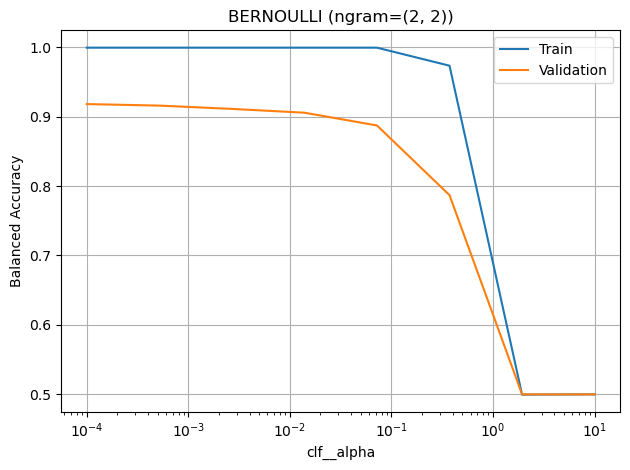

>>>>>>> Model: multinomial


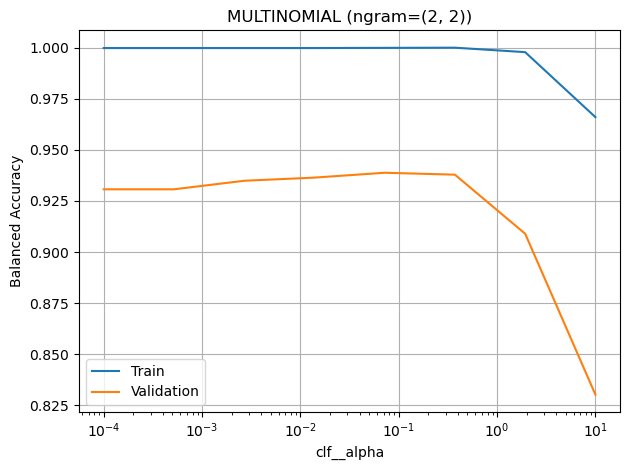


============== N-gram: (1, 2) ==============
>>>>>>> Model: knn


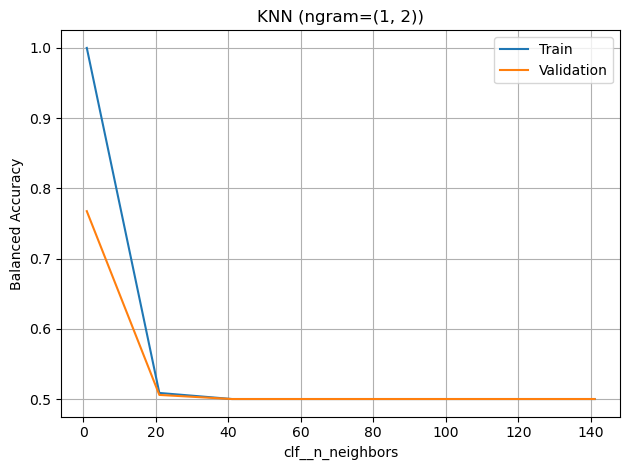

>>>>>>> Model: logreg


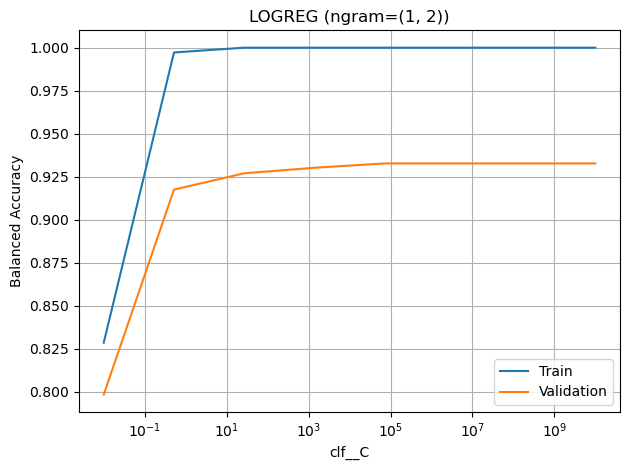

>>>>>>> Model: bernoulli


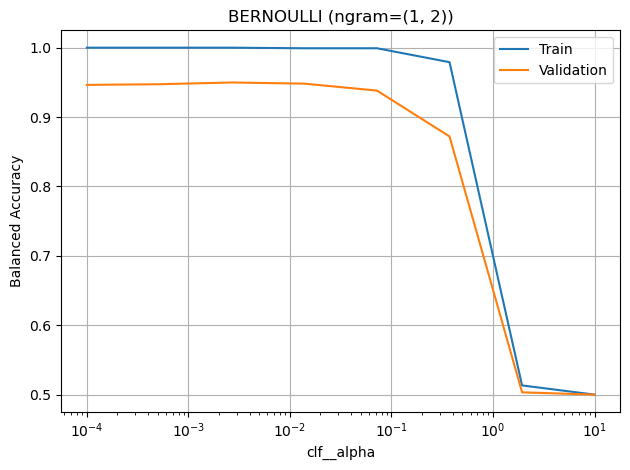

>>>>>>> Model: multinomial


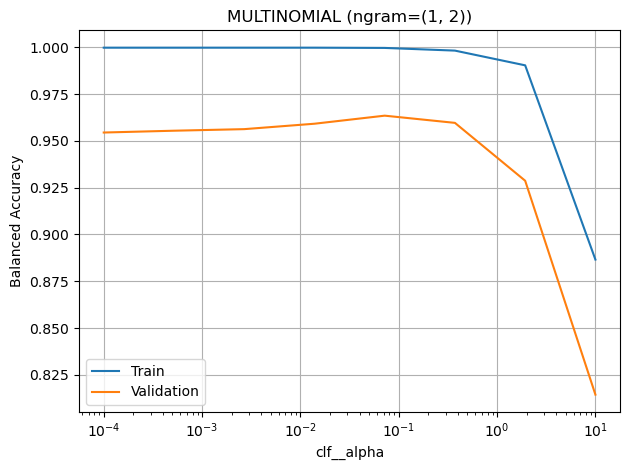


============== Final Results ==============


,Model,N-gram,Best Param,Train Time (s),Predict Time (s),Balanced Accuracy,Precision,Recall,F1-score
10,bernoulli,"(1, 2)",{'clf__alpha': 0.002682695795279727},1.461,0.021,0.979866,1.000000,0.959732,0.979452
2,bernoulli,"(1, 1)",{'clf__alpha': 0.07196856730011521},0.738,0.013,0.976510,1.000000,0.953020,0.975945
11,multinomial,"(1, 2)",{'clf__alpha': 0.07196856730011521},1.383,0.021,0.975725,0.947020,0.959732,0.953333
3,multinomial,"(1, 1)",{'clf__alpha': 0.07196856730011521},1.039,0.015,0.973922,0.965986,0.953020,0.959459
7,multinomial,"(2, 2)",{'clf__alpha': 0.07196856730011521},1.104,0.017,0.966426,0.915584,0.946309,0.930693
6,bernoulli,"(2, 2)",{'clf__alpha': 0.0001},1.012,0.039,0.962052,0.985714,0.926174,0.955017
9,logreg,"(1, 2)",{'clf__C': 71968.56730011514},1.647,0.023,0.959732,1.000000,0.919463,0.958042
1,logreg,"(1, 1)",{'clf__C': 71968.56730011514},0.692,0.012,0.955858,0.992701,0.912752,0.951049
5,logreg,"(2, 2)",{'clf__C': 3727593.720314938},1.214,0.023,0.895973,1.000000,0.791946,0.883895
0,knn,"(1, 1)",{'clf__n_neighbors': 1},4.580,0.105,0.835053,0.990099,0.671141,0.800000


In [44]:
ngram_ranges = [(1, 1), (2, 2), (1, 2)]
results = []

for ngram in ngram_ranges:
    print(f"\n============== N-gram: {ngram} ==============")
    for name, clf in classifiers.items():
        print(f">>>>>>> Model: {name}")
        vectorizer = CountVectorizer(ngram_range=ngram, binary=(name == 'bernoulli'))
        pipeline = Pipeline([
            ('vect', vectorizer),
            ('clf', clf)
        ])
        param_grid = param_grids[name]
        cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=123)
        grid, train_time = run_grid_search(pipeline, param_grid, X_train, y_train, cv)

        # Evaluate best model
        best_model = grid.best_estimator_
        start_pred = time.time()
        metrics = evaluate_model(best_model, X_test, y_test)
        pred_time = time.time() - start_pred

        # Log results
        results.append({
            "Model": name,
            "N-gram": ngram,
            "Best Param": grid.best_params_,
            "Train Time (s)": round(train_time, 3),
            "Predict Time (s)": round(pred_time, 3),
            **metrics
        })

        # Plot scores
        param_name = list(grid.best_params_.keys())[0]
        plot_grid_scores(grid, param_name, f"{name.upper()} (ngram={ngram})")

Выведем накопленные данные в виде таблицы:

In [45]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Balanced Accuracy", ascending=False)

,Model,N-gram,Best Param,Train Time (s),Predict Time (s),Balanced Accuracy,Precision,Recall,F1-score
10,bernoulli,"(1, 2)",{'clf__alpha': 0.002682695795279727},1.461,0.021,0.979866,1.000000,0.959732,0.979452
2,bernoulli,"(1, 1)",{'clf__alpha': 0.07196856730011521},0.738,0.013,0.976510,1.000000,0.953020,0.975945
11,multinomial,"(1, 2)",{'clf__alpha': 0.07196856730011521},1.383,0.021,0.975725,0.947020,0.959732,0.953333
3,multinomial,"(1, 1)",{'clf__alpha': 0.07196856730011521},1.039,0.015,0.973922,0.965986,0.953020,0.959459
7,multinomial,"(2, 2)",{'clf__alpha': 0.07196856730011521},1.104,0.017,0.966426,0.915584,0.946309,0.930693
6,bernoulli,"(2, 2)",{'clf__alpha': 0.0001},1.012,0.039,0.962052,0.985714,0.926174,0.955017
9,logreg,"(1, 2)",{'clf__C': 71968.56730011514},1.647,0.023,0.959732,1.000000,0.919463,0.958042
1,logreg,"(1, 1)",{'clf__C': 71968.56730011514},0.692,0.012,0.955858,0.992701,0.912752,0.951049
5,logreg,"(2, 2)",{'clf__C': 3727593.720314938},1.214,0.023,0.895973,1.000000,0.791946,0.883895
0,knn,"(1, 1)",{'clf__n_neighbors': 1},4.580,0.105,0.835053,0.990099,0.671141,0.800000
